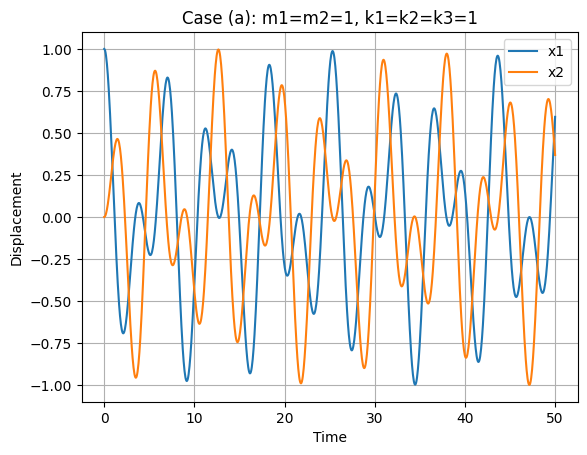

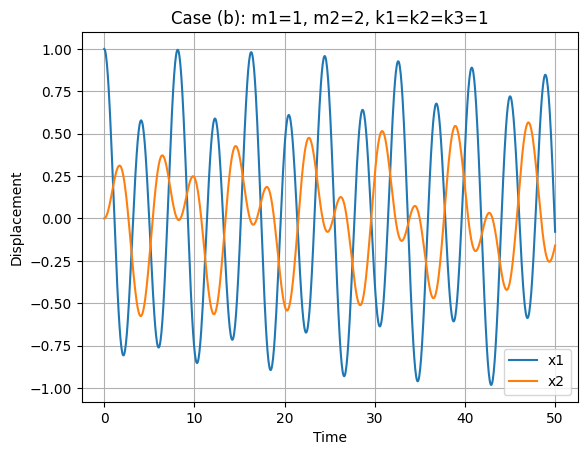

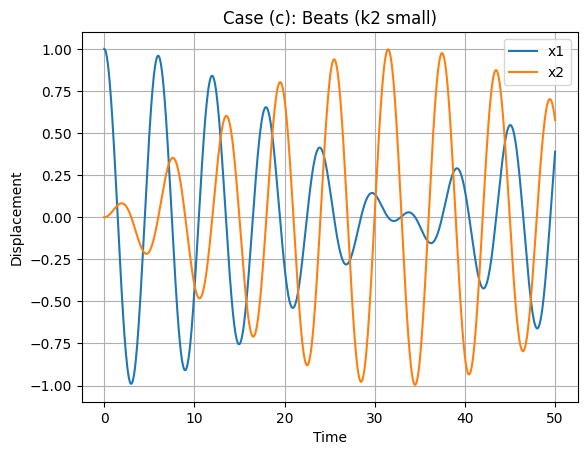

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def coupled(t, y, m1, m2, k1, k2, k3):
    x1, v1, x2, v2 = y

    dx1dt = v1
    dx2dt = v2

    dv1dt = (-(k1 + k2)*x1 + k2*x2) / m1
    dv2dt = (k2*x1 - (k2 + k3)*x2) / m2

    return [dx1dt, dv1dt, dx2dt, dv2dt]


def solve_and_plot(title, m1, m2, k1, k2, k3):
    t_span = (0, 50)
    t_eval = np.linspace(0, 50, 1000)

    y0 = [1, 0, 0, 0]  # initial conditions

    sol = solve_ivp(coupled, t_span, y0, args=(m1, m2, k1, k2, k3), t_eval=t_eval)

    plt.figure()
    plt.plot(sol.t, sol.y[0], label="x1")
    plt.plot(sol.t, sol.y[2], label="x2")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Displacement")
    plt.legend()
    plt.grid()
    plt.show()


solve_and_plot("Case (a): m1=m2=1, k1=k2=k3=1", 1, 1, 1, 1, 1)
solve_and_plot("Case (b): m1=1, m2=2, k1=k2=k3=1", 1, 2, 1, 1, 1)
solve_and_plot("Case (c): Beats (k2 small)", 1, 1, 1, 0.1, 1)

# Coupled Oscillators

## Problem
We are given two masses connected by springs with equations:

m₁ẍ₁ = −(k₁ + k₂)x₁ + k₂x₂  
m₂ẍ₂ = k₂x₁ − (k₂ + k₃)x₂  

We solve these equations numerically and plot x₁(t) and x₂(t) for different parameter values.

---

## Method

1. Convert second-order ODEs into first-order system:
   - Let:
     - x₁ = displacement of mass 1
     - v₁ = velocity of mass 1
     - x₂ = displacement of mass 2
     - v₂ = velocity of mass 2

2. Then:
   - dx₁/dt = v₁
   - dv₁/dt = [−(k₁+k₂)x₁ + k₂x₂] / m₁
   - dx₂/dt = v₂
   - dv₂/dt = [k₂x₁ − (k₂+k₃)x₂] / m₂

3. Solve using numerical solver (`solve_ivp`).

---

## Initial Conditions

x₁(0) = 1, v₁(0) = 0  
x₂(0) = 0, v₂(0) = 0  

---

## Cases

### (a) m₁ = m₂ = 1, k₁ = k₂ = k₃ = 1
- Both oscillators behave symmetrically.
- Energy is exchanged between the masses.

---

### (b) m₁ = 1, m₂ = 2, k₁ = k₂ = k₃ = 1
- Different masses lead to asymmetric motion.
- Oscillation frequencies differ.

---

### (c) m₁ = m₂ = 1, k₁ = k₃ = 1, k₂ = 0.1
- Weak coupling between oscillators.
- **Beats phenomenon observed**:
  - Amplitude modulates slowly.
  - Energy transfers periodically between masses.

---

## Conclusion

- Strong coupling → synchronized motion  
- Weak coupling → beats  
- Mass difference → asymmetric oscillations  

---